In [42]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.kernel_ridge import KernelRidge
import warnings
warnings.filterwarnings('ignore')


In [44]:
# Charger le dataset
#Dataset = pd.read_csv("zara_data.csv", sep=',', decimal=',')
Dataset = pd.read_csv(r"C:\Users\marya\OneDrive\Bureau\Vinted-Zara-scrapping-et-analyse\zara_data.csv", sep=',', decimal=',')
Dataset.head()
Dataset.info()
Dataset.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   nom         333 non-null    str  
 1   url         333 non-null    str  
 2   couleur     319 non-null    str  
 3   matiere     319 non-null    str  
 4   prix        333 non-null    str  
 5   collection  333 non-null    str  
 6   categorie   333 non-null    str  
dtypes: str(7)
memory usage: 18.3 KB


nom            0
url            0
couleur       14
matiere       14
prix           0
collection     0
categorie      0
dtype: int64

In [20]:
Dataset.head(10)

,nom,url,couleur,matiere,prix,collection,categorie
0,ROBE MI-LONGUE FLUIDE,https://www.zara.com/fr/fr/robe-midi-fluide-p0...,Mauve poudré |,88% viscose,"25,99 EUR",femme,ROBE
1,SANDALES À BRIDES ET DÉCOR MÉTALLIQUE,https://www.zara.com/fr/fr/sandales-a-brides-e...,Marron |,100% polyuréthane,"39,95 EUR",femme,SANDALES
2,PNG,https://www.zara.com/fr/fr/pull-asymetrique-en...,NaN,NaN,"25,95 EUR",femme,PNG
3,COMBI-SHORT LYOCELL,https://www.zara.com/fr/fr/combinaison-courte-...,Noir |,100% lyocell,"35,95 EUR",femme,COMBI-SHORT
4,JEAN TRF LOOSE FOLDED TAILLE BASSE À RAYURES,https://www.zara.com/fr/fr/jean-trf-loose-fold...,unique |,100% coton,"35,95 EUR",femme,JEAN
5,ROBE FLUIDE À ENCOLURE AMÉRICAINE,https://www.zara.com/fr/fr/robe-fluide-a-encol...,Vert huile |,86% viscose,"35,95 EUR",femme,ROBE
6,VESTE CROISÉE,https://www.zara.com/fr/fr/veste-croisee-p0438...,brique foncée |,89% viscose,"32,95 EUR",femme,VESTE
7,LOT DE 3 BRACELETS BOIS ET RÉSINE,https://www.zara.com/fr/fr/lot-de-3-bracelets-...,Multicolore |,60% bois de manguier,"19,95 EUR",femme,LOT
8,SANDALES À TALONS IMPRIMÉES,https://www.zara.com/fr/fr/sandales-a-talons-i...,Léopard |,100% polyester,"32,95 EUR",femme,SANDALES
9,SHORT FLUIDE AVEC BOUTONS,https://www.zara.com/fr/fr/short-fluide-a-bout...,Mauve clair |,83% viscose,"22,95 EUR",femme,SHORT


In [21]:
# Supprimer les lignes contenant des valeurs manquantes
print(Dataset[Dataset.isnull().any(axis=1)])

                                                   nom  \
2                                                  PNG   
21                                                 PNG   
57         ONLINE EXCLUSIVE - ZARA HAIR CIRE COIFFANTE   
73   ONLINE EXCLUSIVE - ZARA HAIR GEL FIXATION EXTR...   
78                                                 PNG   
97          ONLINE EXCLUSIVE - ZARA HAIR CIRE EN STICK   
106                                                PNG   
109  ONLINE EXCLUSIVE - POUDRE TEXTURISANTE MATIFIA...   
113                                                PNG   
128                                                PNG   
185                                                PNG   
233                                                PNG   
271                                                PNG   
296                                                PNG   

                                                   url couleur matiere  \
2    https://www.zara.com/fr/fr/pull-asymetrique-en... 

In [45]:
# Supprimer les lignes contenant des valeurs manquantes
Dataset= Dataset.dropna()
Dataset = Dataset.reset_index(drop=True)
print(Dataset.isnull().sum())

nom           0
url           0
couleur       0
matiere       0
prix          0
collection    0
categorie     0
dtype: int64


In [46]:
# Nettoyage de la colonne "prix"
Dataset["prix"] = (
    Dataset["prix"]
    .astype(str)
    .str.replace("EUR", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
)

Dataset["prix"] = pd.to_numeric(
    Dataset["prix"],
    errors="coerce"
)
print(Dataset["prix"].head())
print(Dataset["prix"].isnull().sum())
print(Dataset.dtypes)

0    25.99
1    39.95
2    35.95
3    35.95
4    35.95
Name: prix, dtype: float64
0
nom               str
url               str
couleur           str
matiere           str
prix          float64
collection        str
categorie         str
dtype: object


In [47]:
Dataset["couleur"] = Dataset["couleur"].str.replace("|", "", regex=False).str.strip()

In [51]:
# Nettoyage de la colonne "matiere"
Dataset[["pourcentage", "matiere_principale"]] = (
    Dataset["matiere"]
    .str.extract(r"(\d+)%\s*(.*)")
)
Dataset["pourcentage"] = pd.to_numeric(Dataset["pourcentage"], errors="coerce")
Dataset["matiere_principale"] = Dataset["matiere_principale"].str.strip()
Dataset = Dataset.drop(columns=["matiere"])

In [52]:
# Enregistrer le dataset nettoyé dans un nouveau fichier CSV
Dataset.to_csv("zara_data_clean.csv", index=False)
zara_data_clean = pd.read_csv("zara_data_clean.csv", sep=',')

In [53]:
zara_data_clean.head()

,nom,url,couleur,prix,collection,categorie,pourcentage,matiere_principale
0,ROBE MI-LONGUE FLUIDE,https://www.zara.com/fr/fr/robe-midi-fluide-p0...,Mauve poudré,25.99,femme,ROBE,88,viscose
1,SANDALES À BRIDES ET DÉCOR MÉTALLIQUE,https://www.zara.com/fr/fr/sandales-a-brides-e...,Marron,39.95,femme,SANDALES,100,polyuréthane
2,COMBI-SHORT LYOCELL,https://www.zara.com/fr/fr/combinaison-courte-...,Noir,35.95,femme,COMBI-SHORT,100,lyocell
3,JEAN TRF LOOSE FOLDED TAILLE BASSE À RAYURES,https://www.zara.com/fr/fr/jean-trf-loose-fold...,unique,35.95,femme,JEAN,100,coton
4,ROBE FLUIDE À ENCOLURE AMÉRICAINE,https://www.zara.com/fr/fr/robe-fluide-a-encol...,Vert huile,35.95,femme,ROBE,86,viscose


In [54]:
# Afficher les statistiques descriptives, la forme du dataset et le nombre de valeurs manquantes
print(zara_data_clean.describe())
print(zara_data_clean.shape)
print(zara_data_clean.isnull().sum())

             prix  pourcentage
count  319.000000   319.000000
mean    29.160909    89.492163
std     21.216994    15.984242
min      4.950000    35.000000
25%     15.950000    79.500000
50%     22.950000   100.000000
75%     35.950000   100.000000
max    199.000000   100.000000
(319, 8)
nom                   0
url                   0
couleur               0
prix                  0
collection            0
categorie             0
pourcentage           0
matiere_principale    0
dtype: int64


In [55]:
zara_data_clean.describe()

,prix,pourcentage
count,319.000000,319.000000
mean,29.160909,89.492163
std,21.216994,15.984242
min,4.950000,35.000000
25%,15.950000,79.500000
50%,22.950000,100.000000
75%,35.950000,100.000000
max,199.000000,100.000000


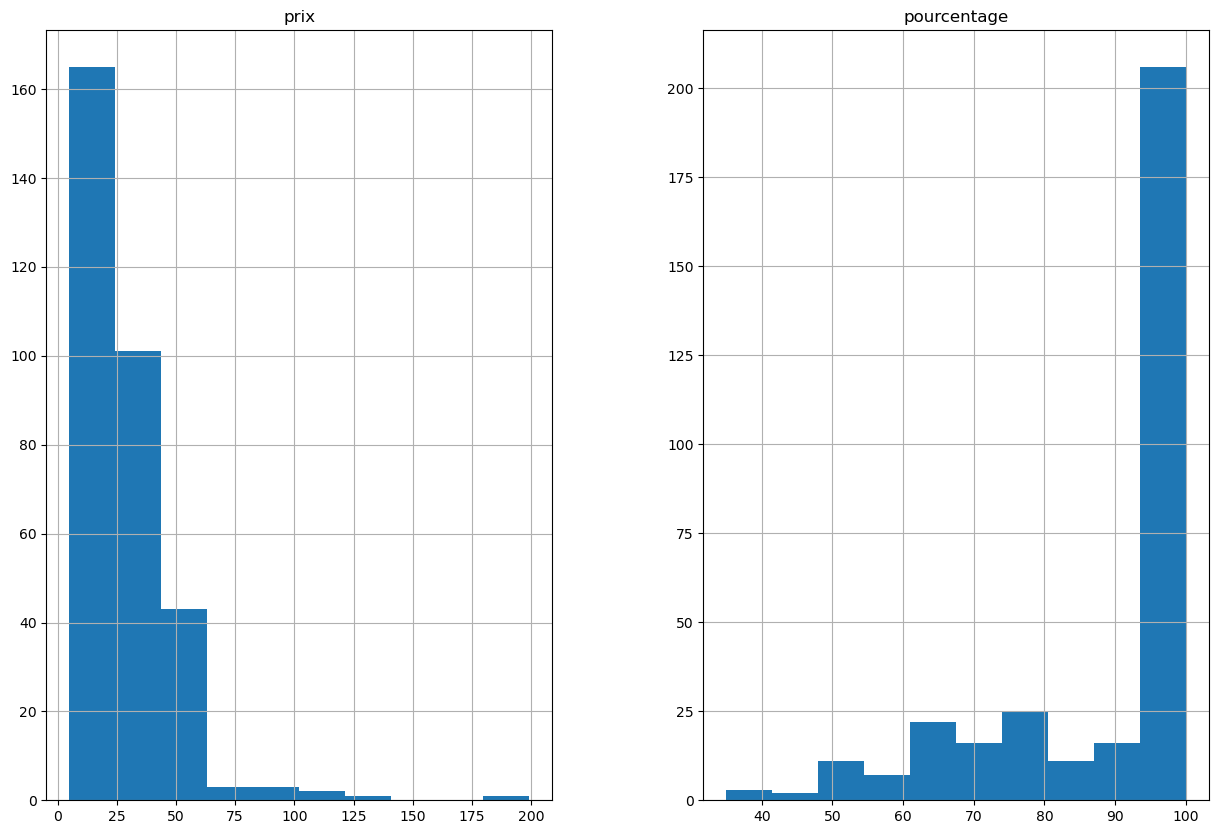

In [56]:
zara_data_clean.hist(figsize=(15,10))
plt.show()

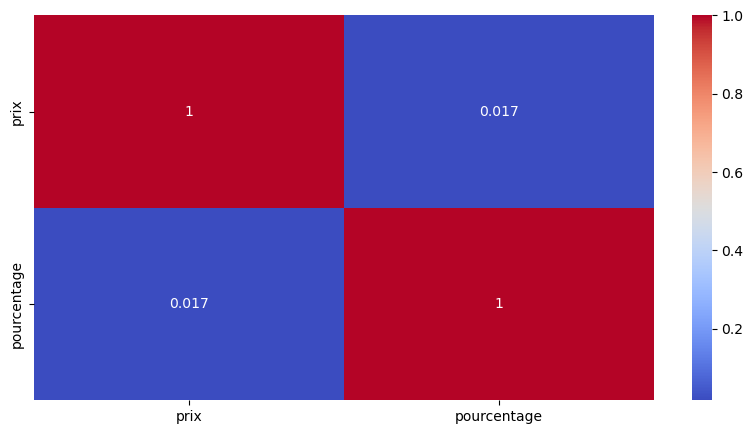

In [57]:
zara_data_clean = zara_data_clean.select_dtypes(include=[np.number])

plt.figure(figsize=(10,5))
sns.heatmap(zara_data_clean.corr(), annot=True, cmap='coolwarm')
plt.show()

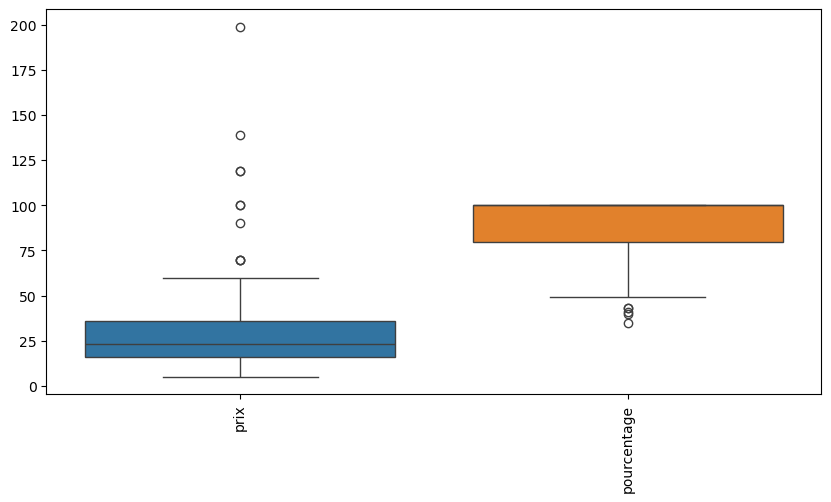

In [58]:
plt.figure(figsize=(10,5))
sns.boxplot(data=zara_data_clean.select_dtypes(include=[np.number]))
plt.xticks(rotation=90)
plt.show()